**Loading the required packages**

In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier

**Loading and seeing the dataset**

In [2]:
# Load the dataset
df = pd.read_csv('developer_burnout_dataset_7000.csv')

In [3]:
# see the data

df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [4]:
# see the info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [5]:
# check missing values

df.isnull().sum()

,0
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


# **Data Preprocessing**

**Feature Engineering**

In [6]:
# Make new feature is_robot
df['is_robot'] = df['burnout_level'].apply(lambda x: 1 if x == 'High' else 0)

In [7]:
# Select all relevant numerical features
features = [
    'age', 'experience_years', 'daily_work_hours', 'sleep_hours',
    'caffeine_intake', 'bugs_per_day', 'commits_per_day',
    'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level'
]

**Feature and Target**

In [8]:
# separate features and target
X = df[features]
y = df['is_robot']

Data loaded and I have seperated features.

**Train Test Split**

In [9]:
# split the data into 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

**Solving Missing Values**

In [10]:
# I will use KNNImputer to solve and fill any missing values based on neighboring data
imputer = KNNImputer(n_neighbors=5)

# Fit and transform the data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values successfully filled.")

Missing values successfully filled.


**Check Missing Values**

In [11]:
# check missing values again to see if they are solved

# Check Train Data
print("Missing value for train before:", X_train.isnull().sum().sum())
print("Missing value for train after:", np.isnan(X_train_imputed).sum())

# Check Test Data
print("Missing value for test before", X_test.isnull().sum().sum())
print("Missing value for test after:", np.isnan(X_test_imputed).sum())

Missing value for train before: 1214
Missing value for train after: 0
Missing value for test before 326
Missing value for test after: 0


We can see that missing values are solved.

**Scaling Features**

In [12]:
# I will use MinMaxScaler to scale all features so they have equal weight in the model
scaler = MinMaxScaler()

# Fit and transform the already-imputed data
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Features successfully scaled to equal weights.")

Features successfully scaled to equal weights.


# **Model Training**

For training phrase, I will use KNN method. SO, first, I will find best K value

**Hyperparameter Tuning**

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score

In [14]:
# make a range of k values to test (using odd numbers 1 to 19 to prevent ties)
k_list = range(1, 20, 2)
best_k = 0
best_score = 0

# find the best k
for k in k_list:
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # I used cv=5 for Bias-Variance Tradeoff
    scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_k = k

print(f"The best number of neighbors (k) is: {best_k} (Cross-Validation Accuracy: {best_score*100:.2f}%)")

The best number of neighbors (k) is: 15 (Cross-Validation Accuracy: 91.11%)


In [15]:
# train the KNeighborsClassifier  using the BEST k I just found
model = KNeighborsClassifier(n_neighbors=best_k)

In [16]:
# Fit the model using the training data
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=15)

In [17]:
print("Final model successfully trained!")

Final model successfully trained!


# **Model Testing**

**Accuracy Score**

In [18]:
from sklearn.metrics import accuracy_score

# Test the model to see what it predicts for the test data
y_pred = model.predict(X_test_scaled)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy Score: {accuracy * 100:.2f}%")

Model Accuracy Score: 92.43%


**Classification Report**

In [19]:
# I will make a classification report to see precision, recall and f1-score for each
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Human (0)', 'Robot (1)']))

              precision    recall  f1-score   support

   Human (0)       0.94      0.96      0.95      1077
   Robot (1)       0.86      0.80      0.83       323

    accuracy                           0.92      1400
   macro avg       0.90      0.88      0.89      1400
weighted avg       0.92      0.92      0.92      1400



**Precision, recall and F-1 score**

In [20]:
# We can see precision, recall and f1-score in the above but I want to show for each again
from sklearn.metrics import precision_score, recall_score, f1_score

# Precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision * 100:.2f}%")

# Recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall:    {recall * 100:.2f}%")

# F1-Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score:  {f1 * 100:.2f}%")

Precision: 92.30%
Recall:    92.43%
F1-Score:  92.33%


**Confusion Matrix Visualization**

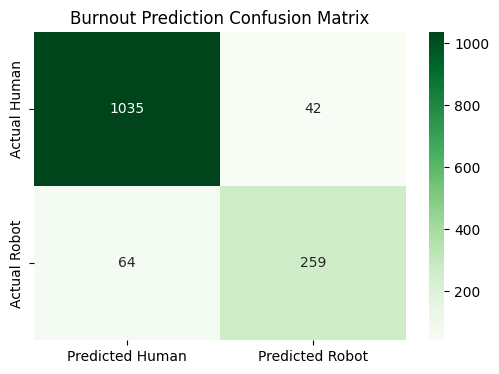

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Human', 'Predicted Robot'],
            yticklabels=['Actual Human', 'Actual Robot'])
plt.title('Burnout Prediction Confusion Matrix')
plt.show()

**Which feature affeect the target label the most?**

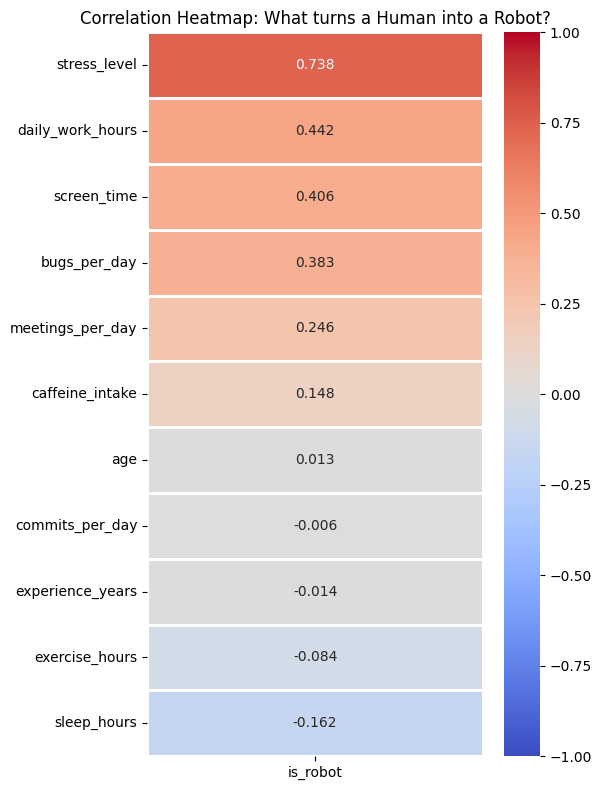

In [22]:
# Calculate how much each feature correlates with being a 'Robot' (1)
correlations = df[features + ['is_robot']].corr()[['is_robot']].drop('is_robot')

# Sort them from highest positive impact to highest negative impact
correlations = correlations.sort_values(by='is_robot', ascending=False)

# Plot the Correlation Heatmap
plt.figure(figsize=(6, 8))
# 'coolwarm' shows Red for Robot (Danger) and Blue for Human (Safe)
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', linewidths=1, linecolor='white')
plt.title('Correlation Heatmap: What turns a Human into a Robot?')
plt.tight_layout()
plt.show()

**Save the Pipeline**

In [23]:
# Save all three tools into a single dictionary so Flask can use them
data_to_save = {
    'model': model,
    'scaler': scaler,
    'imputer': imputer
}

In [24]:
# Create the .pkl file
with open('model.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

print("Model, Scaler, and Imputer saved as model.pkl!")

Model, Scaler, and Imputer saved as model.pkl!
